## Imports
---

In [2]:
# Core
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import scipy.sparse as sparse

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model, Sequential, load_model, save_model
from tensorflow.keras.layers import (
    Activation,
    Input,
    Dense,
    Dropout,
    Flatten,
    Reshape,
    Conv2D,
    Conv2DTranspose,
    GlobalAveragePooling2D,
    MaxPooling2D,
    AveragePooling2D,
    UpSampling2D,
    BatchNormalization,
    Concatenate,
    RepeatVector,
    Lambda,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy, categorical_crossentropy
from tensorflow.keras.utils import plot_model
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

# Visualization
import seaborn as sns
from matplotlib import font_manager as fm

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

/Users/oliviajackson/Documents/Education/Personal Projects/high-energy-particle-classifier/.venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [4]:
# Setting directory paths
working_dir = "../models"
figures_dir = "../figures"

In [5]:
# Adding custom fonts
fm.fontManager.addfont("../assets/fonts/Lora-Regular.ttf")
fm.fontManager.addfont("../assets/fonts/Lora-SemiBold.ttf")

# Setting matplotlib parameters
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "font.size": 11,
    "font.family": "Lora",
    "axes.titlesize": 12,
    "axes.titleweight": "semibold",
    "axes.labelsize": 10,
})

# Defining color scheme
train_color = "#3A506B"   # muted slate blue
val_color   = "#9E2A2B"   # muted rust red

## Loading in the Dataset
---
There are eight arrays present in the dataset

- The particle ID (particle type ID as defined by the [particle data group](https://pdg.lbl.gov/2007/reviews/montecarlorpp.pdf))
    - 11   : electron
    - 22   : photon
    - 13   : muon
    - 211  : pion
    - 2212 : proton
- The total momentum (p) of the initial particle in MeV
- The x component (px) of momentum in MEV
- The y component (py) of momentum in MEV
- The x component (pz) of momentum in MEV
- The x position of the production of the particle in cm
- The y position of the production of the particle in cm
- The z position of the production of the particle in cm

In [6]:
# Dataset Information
particle_IDs = [11.0, 22.0, 13.0, 211.0, 2212.0]
particle_names = ['Electron', 'Positron', 'Muon', 'Pion', 'Proton']
projections = ['X-Y', 'Y-Z', 'Z-X']
no_classes = len(particle_IDs)
no_projections = len(projections)

In [7]:
images = sparse.load_npz("../data/particle_images.npz")
print(type(images), images.shape, np.prod(images.shape))

<class 'scipy.sparse._csr.csr_matrix'> (90000, 196608) 17694720000


In [8]:
truth = np.load("../data/particle_truth_array.npy")
p_id , p_ptot, p_px, p_py, p_pz, p_x, p_y, p_z = (truth[:,i] for i in range(truth.shape[1]))
print(truth.shape)

(90000, 8)


## Utility Functions
---
### Function to Convert from Sparse to Dense Images

In [9]:
def to_image(sparse_array):
    # Convert to dense array, and reshape to three 2D images
    reshape = sparse_array.toarray().reshape((256, 256, 3))
    return reshape[:,:,0], reshape[:,:,1], reshape[:,:,2]

### Function for Generating Batches of Dense Data

In [10]:
def nn_batch_generator(X, y, batch_size = 32, shuffle = True):
    n = X.shape[0]
    idx = np.arange(n)

    while True:
        if shuffle:
            np.random.shuffle(idx)

        for start in range(0, n, batch_size):
            batch_idx = idx[start:start + batch_size]

            Xb = X[batch_idx]
            yb = y[batch_idx]

            # If X is sparse, convert just the batch
            if hasattr(Xb, "toarray"):
                Xb = Xb.toarray()

            yield Xb.astype(np.float32), yb.astype(np.float32)

## Data Pre-processing
---

### Splitting the Dataset into Training and Testing Sets
50K for training, and 40K reserved for testing

In [11]:
x_train, x_test, truth_train, truth_test = train_test_split(images, truth, train_size = 50000, random_state = 11)

### One-Hot Encoding the Dataset 
The raw data is assigned numbers that range from 11 - 2212. One hot encoding the data will make things simpler as now the particle type will be assigned a value from 1-5 instead.

In [12]:
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=float)
type_train = enc.fit_transform(truth_train[:, 0].reshape(-1, 1))
type_test  = enc.transform(truth_test[:, 0].reshape(-1, 1))

## Convolution Neural Network Image Classifier - Initial Model
---

TBD

In [10]:
# Input is flattened; reshape back into (256, 256, 3)
inputs = Input(shape=(196608,))
x = Reshape((256, 256, 3))(inputs)

def conv_block(x, filters, stride=1, drop=0.0):
    # Conv → BN → ReLU
    x = Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # Second conv in the block
    x = Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # Downsample
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Light dropout for regularization
    if drop > 0:
        x = Dropout(drop)(x)

    return x

# Feature extraction blocks (increasing filters)
x = conv_block(x, 16, stride=2, drop=0.10)
x = conv_block(x, 32, drop=0.15)
x = conv_block(x, 64, drop=0.20)

# Compact representation
x = GlobalAveragePooling2D()(x)

# Small dense head
x = Dense(64, activation="relu")(x)
x = Dropout(0.25)(x)

# 5-way classification
outputs = Dense(5, activation="softmax")(x)

cnn = Model(inputs, outputs)

# Showing the model summary
cnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 196608)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 16)   │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 77,237 (301.71 KB)

 Trainable params: 76,789 (299.96 KB)

 Non-trainable params: 448 (1.75 KB)

### Training Parameters

Before training the model, I set up callbacks to speed up the process as much as possible. In these callbacks the best model over all epochs is also saved for later reloading if necessary. Parameters for the fitting are also set here.

In [14]:
# Shuffling training data
rng = np.random.default_rng(42)   # fixed seed for reproducibility
perm = rng.permutation(x_train.shape[0])

x_train = x_train[perm]
type_train = type_train[perm]

# Setting training parameters
name = "initial_model"
validation_slice = 5000
batch_size = 32
n = x_train.shape[0]
init_epochs = 5
train_steps = int((n - validation_slice) / batch_size)

In [15]:
# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_cat_acc",
        mode="max",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(working_dir, f"{name}.keras"),
        monitor="val_cat_acc",
        mode="max",
        save_best_only=True,
        verbose=0
    )
]

### Compilation and Training
The CNN is compiled with the ADAM optimiser and binary cross entropy is used for calculating the loss to be minimised. Accuracy is used for evaluation.
The model is then trained on the image training dataset in small batches fed into the `nn_batch_generator` function, with 5000 examples set apart from the set for validation.

In [16]:
# Compiling and training
cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=[tf.keras.metrics.CategoricalAccuracy(name="cat_acc")])

history_cnn = cnn.fit(
    nn_batch_generator(
        x_train[: n - validation_slice],
        type_train[: n - validation_slice],
        batch_size=batch_size
    ),
    epochs=init_epochs,
    steps_per_epoch=train_steps,
    validation_data=(x_train[n - validation_slice :], type_train[n - validation_slice :]),
    callbacks=callbacks
)

Epoch 1/5
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 301s 213ms/step - cat_acc: 0.6639 - loss: 0.7107 - val_cat_acc: 0.6096 - val_loss: 0.7340 - learning_rate: 0.0010
Epoch 2/5
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 282s 200ms/step - cat_acc: 0.7219 - loss: 0.5818 - val_cat_acc: 0.7472 - val_loss: 0.6209 - learning_rate: 0.0010
Epoch 3/5
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 290s 206ms/step - cat_acc: 0.7634 - loss: 0.5292 - val_cat_acc: 0.8008 - val_loss: 0.4950 - learning_rate: 0.0010
Epoch 4/5
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 299s 213ms/step - cat_acc: 0.8004 - loss: 0.4723 - val_cat_acc: 0.8344 - val_loss: 0.4219 - learning_rate: 0.0010
Epoch 5/5
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 298s 212ms/step - cat_acc: 0.8273 - loss: 0.4277 - val_cat_acc: 0.5362 - val_loss: 1.1053 - learning_rate: 0.0010


### Predicting Labels

After the traning is complete, the CNN is used to predict the particle types of the images from the training set and then the accuracy of the model is calculated with the `evaluate` method.

In [17]:
# Evaluation on test set
test_loss, test_cat_acc = cnn.evaluate(x_test, type_test, batch_size=50, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test categorical accuracy: {test_cat_acc:.4f}")

800/800 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - cat_acc: 0.8290 - loss: 0.4262
Test loss: 0.4262
Test categorical accuracy: 0.8290


In [18]:
# Predict classes
y_pred = cnn.predict(x_test, batch_size=50)
y_pred_cls = np.argmax(y_pred, axis=1)
y_true_cls = np.argmax(type_test, axis=1)

800/800 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step


## Evaluation Figures
---

In [23]:
epochs = np.arange(1, init_epochs + 1)

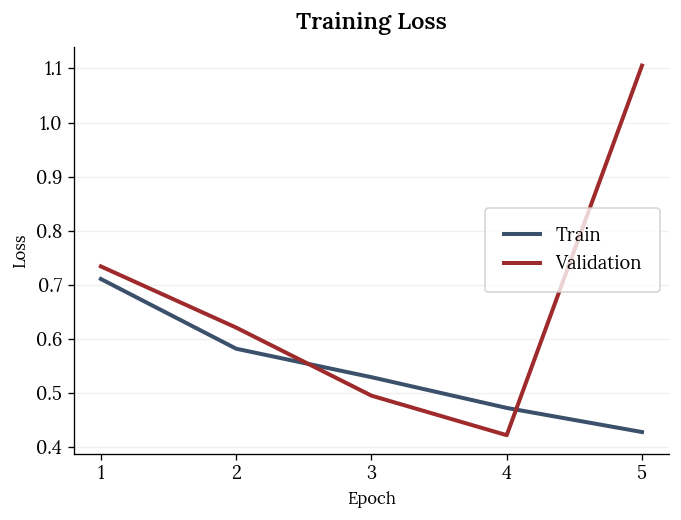

Saved: ../figures/init_cnn_training_loss.png


In [24]:
# Loss Figure
fig, ax = plt.subplots(figsize=(6.4, 4.4))

ax.plot(epochs, history_cnn.history["loss"], label="Train", linewidth=2.4, color=train_color)
ax.plot(epochs, history_cnn.history["val_loss"], label="Validation", linewidth=2.4, color=val_color)

ax.set_title("Training Loss", fontsize=14, fontweight="bold", y=1.02)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_xticks(epochs)

ax.grid(True, axis="y", alpha=0.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(fontsize=11, borderpad = 1, loc='right')

out_path = os.path.join(figures_dir, "init_cnn_training_loss.png")
fig.savefig(out_path, dpi=220, bbox_inches="tight", pad_inches=0.02)
plt.show()
plt.close(fig)

print(f"Saved: {out_path}")

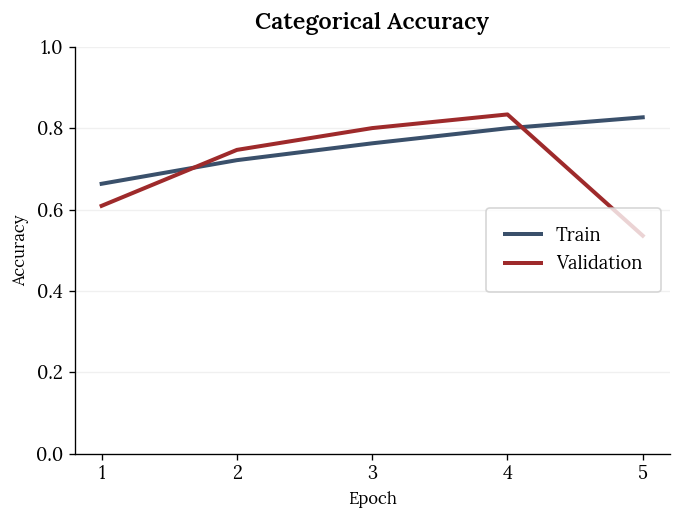

Saved: ../figures/init_cnn_training_accuracy.png


In [25]:
# Accuracy Figure
fig, ax = plt.subplots(figsize=(6.4, 4.4))

ax.plot(epochs, history_cnn.history["cat_acc"], label="Train", linewidth=2.4, color=train_color)
ax.plot(epochs, history_cnn.history["val_cat_acc"], label="Validation", linewidth=2.4, color=val_color)

ax.set_title("Categorical Accuracy", fontsize=14, fontweight="bold", y=1.02)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_xticks(epochs)
ax.set_ylim(0, 1)

ax.grid(True, axis="y", alpha=0.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(fontsize=11, borderpad = 1, loc='right')

out_path = os.path.join(figures_dir, "init_cnn_training_accuracy.png")
fig.savefig(out_path, dpi=220, bbox_inches="tight", pad_inches=0.02)
plt.show()
plt.close(fig)

print(f"Saved: {out_path}")

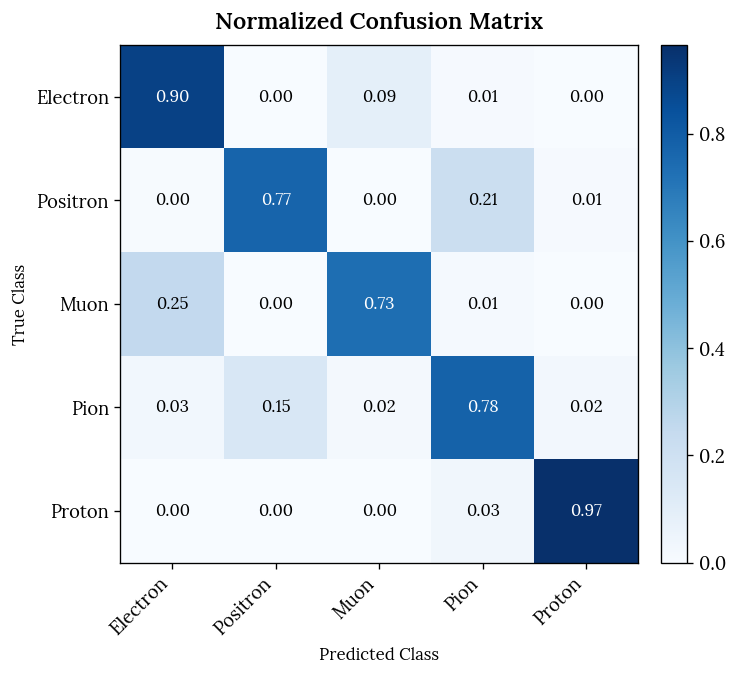

Saved: ../figures/init_cnn_confusion_matrix.png


In [28]:
# Confusion Matrix Figure
cm = confusion_matrix(y_true_cls, y_pred_cls)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6.2, 5.6))

im = ax.imshow(cm_norm, cmap="Blues")

ax.set_title("Normalized Confusion Matrix", fontsize=14, fontweight="bold", pad=10)
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")

ax.set_xticks(np.arange(len(particle_names)))
ax.set_yticks(np.arange(len(particle_names)))
ax.set_xticklabels(particle_names, rotation=45, ha="right")
ax.set_yticklabels(particle_names)

# Annotate cells
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(
            j, i,
            f"{cm_norm[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if cm_norm[i, j] > 0.5 else "black",
            fontsize=10
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

out_path = os.path.join(figures_dir, "init_cnn_confusion_matrix.png")
fig.savefig(out_path, dpi=220, bbox_inches="tight", pad_inches=0.02)
plt.show()
plt.close(fig)

print(f"Saved: {out_path}")

## Dynamic Convolution Neural Network Builder Function
---

Here I design a function to dynamically create convolutional neural networks with different architectures. The function is based on the structure of the first CNN but it can accept varying numbers of convolution, pooling and dropout layers depending on what is input as well as unique numbers of filters or nodes. I wrote this to enable the automation of hyperparameter optimisation.

In [29]:
def make_cnn_from_config(cfg, input_dim=196608, n_classes=5):
    filters = cfg.get("filters", (16, 32, 64))
    dropout_blocks = cfg.get("dropout_blocks", (0.10, 0.15, 0.20))
    dense_units = cfg.get("dense_units", 64)
    dropout_head = cfg.get("dropout_head", 0.25)
    lr = cfg.get("lr", 1e-3)
    pool = cfg.get("pool", "max")  # "max" or "avg"
    use_batchnorm = cfg.get("batchnorm", True)

    Pool = layers.MaxPooling2D if pool == "max" else layers.AveragePooling2D

    def conv_block(x, f, stride=1):
        # Conv -> BN -> ReLU
        x = layers.Conv2D(f, 3, strides=stride, padding="same", use_bias=not use_batchnorm)(x)
        if use_batchnorm:
            x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)

        # Conv -> BN -> ReLU
        x = layers.Conv2D(f, 3, padding="same", use_bias=not use_batchnorm)(x)
        if use_batchnorm:
            x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        return x

    inp = Input(shape=(input_dim,))
    x = layers.Reshape((256, 256, 3))(inp)

    for i, f in enumerate(filters):
        stride = 2 if i == 0 else 1
        x = conv_block(x, f, stride=stride)
        x = Pool(pool_size=(2, 2))(x)

        dr = dropout_blocks[i] if i < len(dropout_blocks) else dropout_blocks[-1]
        x = layers.Dropout(dr)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout_head)(x)
    out = layers.Dense(n_classes, activation="softmax")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=[tf.keras.metrics.CategoricalAccuracy(name="cat_acc")]
    )
    return model

## Hyperparameter Optimisation
---

Here I create a Python dictionary with different input values to the `make_cnn()` function and then create a grid with all of the combinations of these values to iterate through. These values are based on the results of my first CNN, which was a relatively accurate starting point.

In [30]:
model_grid = {
    # -------------------------
    # Reference / baseline
    # -------------------------
    "baseline": {
        "filters": (16, 32, 64),
        "dense_units": 64,
        "dropout_blocks": (0.10, 0.15, 0.20),
        "dropout_head": 0.25,
        "pool": "max",
        "batchnorm": True,
        "lr": 1e-3,
    },

    # -------------------------
    # Capacity (one change)
    # -------------------------
    "wider_filters_only": {
        # only filters changed
        "filters": (24, 48, 96),
        "dense_units": 64,
        "dropout_blocks": (0.10, 0.15, 0.20),
        "dropout_head": 0.25,
        "pool": "max",
        "batchnorm": True,
        "lr": 1e-3,
    },
    "bigger_head_only": {
        # only dense head changed
        "filters": (16, 32, 64),
        "dense_units": 128,
        "dropout_blocks": (0.10, 0.15, 0.20),
        "dropout_head": 0.25,
        "pool": "max",
        "batchnorm": True,
        "lr": 1e-3,
    },

    # -------------------------
    # Pooling (one change)
    # -------------------------
    "avg_pooling": {
        "filters": (16, 32, 64),
        "dense_units": 64,
        "dropout_blocks": (0.10, 0.15, 0.20),
        "dropout_head": 0.25,
        "pool": "avg",
        "batchnorm": True,
        "lr": 1e-3,
    },

    # -------------------------
    # Regularization (one change)
    # -------------------------
    "less_dropout": {
        # only dropout changed
        "filters": (16, 32, 64),
        "dense_units": 64,
        "dropout_blocks": (0.05, 0.10, 0.10),
        "dropout_head": 0.15,
        "pool": "max",
        "batchnorm": True,
        "lr": 1e-3,
    },
    "more_dropout": {
        # only dropout changed (in case you’re under-regularized)
        "filters": (16, 32, 64),
        "dense_units": 64,
        "dropout_blocks": (0.15, 0.20, 0.25),
        "dropout_head": 0.35,
        "pool": "max",
        "batchnorm": True,
        "lr": 1e-3,
    },

    # -------------------------
    # Optimizer / LR (one change)
    # -------------------------
    "lr_lower": {
        "filters": (16, 32, 64),
        "dense_units": 64,
        "dropout_blocks": (0.10, 0.15, 0.20),
        "dropout_head": 0.25,
        "pool": "max",
        "batchnorm": True,
        "lr": 3e-4,
    },
    "lr_higher": {
        "filters": (16, 32, 64),
        "dense_units": 64,
        "dropout_blocks": (0.10, 0.15, 0.20),
        "dropout_head": 0.25,
        "pool": "max",
        "batchnorm": True,
        "lr": 2e-3,
    },

    # -------------------------
    # BatchNorm ablation (one change)
    # -------------------------
    "no_batchnorm": {
        "filters": (16, 32, 64),
        "dense_units": 64,
        "dropout_blocks": (0.10, 0.15, 0.20),
        "dropout_head": 0.25,
        "pool": "max",
        "batchnorm": False,
        "lr": 1e-3,
    },
}

### First Round

In [32]:
hyper_epochs = 30
n = x_train.shape[0]
n_train = n - validation_slice

X_tr = x_train[:n_train]
y_tr = type_train[:n_train]
X_val = x_train[n_train:]
y_val = type_train[n_train:]

In [33]:
def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [35]:
# Convert validation set once if sparse (faster + more stable)
if hasattr(X_val, "toarray"):
    X_val_dense = X_val.toarray().astype(np.float32)
else:
    X_val_dense = X_val.astype(np.float32)

results = {}

for name, cfg in model_grid.items():
    print(f"\n===== Training: {name} =====")
    set_seeds(42)
    tf.keras.backend.clear_session()

    model = make_cnn_from_config(cfg)

    hist = model.fit(
        nn_batch_generator(X_tr, y_tr, batch_size=batch_size, shuffle=True),
        steps_per_epoch=train_steps,
        epochs=hyper_epochs,
        validation_data=(X_val_dense, y_val.astype(np.float32)),
        callbacks=callbacks,
        verbose=1
    )

    best_val = float(np.max(hist.history["val_cat_acc"]))
    results[name] = {
        "config": cfg,
        "best_val_cat_acc": best_val,
        "final_val_cat_acc": float(hist.history["val_cat_acc"][-1]),
        "final_val_loss": float(hist.history["val_loss"][-1]),
    }

# Print a ranked summary
ranked = sorted(results.items(), key=lambda kv: kv[1]["best_val_cat_acc"], reverse=True)
print("\n=== Ranked by best validation categorical accuracy ===")
for name, r in ranked:
    print(f"{name:15s}  best_val_cat_acc={r['best_val_cat_acc']:.4f}  final_val_loss={r['final_val_loss']:.4f}")


===== Training: baseline =====
Epoch 1/30
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 308s 218ms/step - cat_acc: 0.6639 - loss: 0.7107 - val_cat_acc: 0.6096 - val_loss: 0.7340 - learning_rate: 0.0010
Epoch 2/30
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - cat_acc: 0.7093 - loss: 0.6018
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 317s 226ms/step - cat_acc: 0.7219 - loss: 0.5818 - val_cat_acc: 0.7472 - val_loss: 0.6209 - learning_rate: 0.0010
Epoch 3/30
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 300s 213ms/step - cat_acc: 0.7694 - loss: 0.5150 - val_cat_acc: 0.7510 - val_loss: 0.5286 - learning_rate: 2.0000e-04
Epoch 4/30
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - cat_acc: 0.7822 - loss: 0.4949
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 287s 204ms/step - cat_acc: 0.7877 - loss: 0.4909 - val_cat_acc: 0.8134 - val_loss: 0.4640 - learning_rate: 2.0000e-04

===== Training: wider_fil

=== Ranked by best validation categorical accuracy ===
lr_higher        best_val_cat_acc=0.8322  final_val_loss=0.4099
less_dropout     best_val_cat_acc=0.8144  final_val_loss=0.4621
baseline         best_val_cat_acc=0.8134  final_val_loss=0.4640
avg_pooling      best_val_cat_acc=0.8056  final_val_loss=0.4582
more_dropout     best_val_cat_acc=0.7900  final_val_loss=0.5007
wider_filters_only  best_val_cat_acc=0.7820  final_val_loss=0.4812
no_batchnorm     best_val_cat_acc=0.7632  final_val_loss=0.5254
bigger_head_only  best_val_cat_acc=0.7588  final_val_loss=0.5151
lr_lower         best_val_cat_acc=0.7210  final_val_loss=0.6066

### Second Round

In [40]:
# Remove LR Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_cat_acc",
        mode="max",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(working_dir, f"{name}.keras"),
        monitor="val_cat_acc",
        mode="max",
        save_best_only=True,
        verbose=0
    )
]

In [41]:
model_grid = {
    "lr_1e-3_baseline": {
        "filters": (16, 32, 64),
        "dense_units": 64,
        "dropout_blocks": (0.10, 0.15, 0.20),
        "dropout_head": 0.25,
        "pool": "max",
        "batchnorm": True,
        "lr": 1e-3,
    },
    "lr_1p2e-3": {
        "filters": (16, 32, 64),
        "dense_units": 64,
        "dropout_blocks": (0.10, 0.15, 0.20),
        "dropout_head": 0.25,
        "pool": "max",
        "batchnorm": True,
        "lr": 1.2e-3,
    },
    "lr_1p5e-3": {
        "filters": (16, 32, 64),
        "dense_units": 64,
        "dropout_blocks": (0.10, 0.15, 0.20),
        "dropout_head": 0.25,
        "pool": "max",
        "batchnorm": True,
        "lr": 1.5e-3,
    },
    "lr_2e-3": {
        "filters": (16, 32, 64),
        "dense_units": 64,
        "dropout_blocks": (0.10, 0.15, 0.20),
        "dropout_head": 0.25,
        "pool": "max",
        "batchnorm": True,
        "lr": 2e-3,
    },
    "lr_3e-3": {
        "filters": (16, 32, 64),
        "dense_units": 64,
        "dropout_blocks": (0.10, 0.15, 0.20),
        "dropout_head": 0.25,
        "pool": "max",
        "batchnorm": True,
        "lr": 3e-3,
    },
}

In [43]:
# Convert validation set once if sparse (faster + more stable)
hyper_epochs = 25

if hasattr(X_val, "toarray"):
    X_val_dense = X_val.toarray().astype(np.float32)
else:
    X_val_dense = X_val.astype(np.float32)

results = {}

for name, cfg in model_grid.items():
    print(f"\n===== Training: {name} =====")
    set_seeds(42)
    tf.keras.backend.clear_session()

    model = make_cnn_from_config(cfg)

    hist = model.fit(
        nn_batch_generator(X_tr, y_tr, batch_size=batch_size, shuffle=True),
        steps_per_epoch=train_steps,
        epochs=hyper_epochs,
        validation_data=(X_val_dense, y_val.astype(np.float32)),
        callbacks=callbacks,
        verbose=1
    )

    best_val = float(np.max(hist.history["val_cat_acc"]))
    results[name] = {
        "config": cfg,
        "best_val_cat_acc": best_val,
        "final_val_cat_acc": float(hist.history["val_cat_acc"][-1]),
        "final_val_loss": float(hist.history["val_loss"][-1]),
    }

# Print a ranked summary
ranked = sorted(results.items(), key=lambda kv: kv[1]["best_val_cat_acc"], reverse=True)
print("\n=== Ranked by best validation categorical accuracy ===")
for name, r in ranked:
    print(f"{name:15s}  best_val_cat_acc={r['best_val_cat_acc']:.4f}  final_val_loss={r['final_val_loss']:.4f}")


===== Training: lr_1e-3_baseline =====
Epoch 1/25
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 288s 204ms/step - cat_acc: 0.6639 - loss: 0.7107 - val_cat_acc: 0.6096 - val_loss: 0.7340
Epoch 2/25
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 276s 197ms/step - cat_acc: 0.7219 - loss: 0.5818 - val_cat_acc: 0.7472 - val_loss: 0.6209
Epoch 3/25
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 282s 200ms/step - cat_acc: 0.7634 - loss: 0.5292 - val_cat_acc: 0.8008 - val_loss: 0.4950
Epoch 4/25
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 285s 202ms/step - cat_acc: 0.8004 - loss: 0.4723 - val_cat_acc: 0.8344 - val_loss: 0.4219

===== Training: lr_1p2e-3 =====
Epoch 1/25
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 276s 196ms/step - cat_acc: 0.6652 - loss: 0.7045 - val_cat_acc: 0.3612 - val_loss: 1.6415
Epoch 2/25
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 274s 195ms/step - cat_acc: 0.7204 - loss: 0.5782 - val_cat_acc: 0.6476 - val_loss: 0.6732
Epoch 3/25
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 272s 193ms/step - cat_acc: 0.7560 - loss: 0.5308 - val_cat_acc: 0.3122 - val_loss: 8.3923
Epo

### Third Round
Learning rates are the same but the ReduceLROnPlateau callback has been adjusted to reduce the learning rate more aggressively.

In [46]:
# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_cat_acc",
        mode="max",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        os.path.join(working_dir, f"{name}.keras"),
        monitor="val_cat_acc",
        mode="max",
        save_best_only=True,
        verbose=0
    )
]

In [47]:
# Convert validation set once if sparse (faster + more stable)
hyper_epochs = 25

if hasattr(X_val, "toarray"):
    X_val_dense = X_val.toarray().astype(np.float32)
else:
    X_val_dense = X_val.astype(np.float32)

results = {}

for name, cfg in model_grid.items():
    print(f"\n===== Training: {name} =====")
    set_seeds(42)
    tf.keras.backend.clear_session()

    model = make_cnn_from_config(cfg)

    hist = model.fit(
        nn_batch_generator(X_tr, y_tr, batch_size=batch_size, shuffle=True),
        steps_per_epoch=train_steps,
        epochs=hyper_epochs,
        validation_data=(X_val_dense, y_val.astype(np.float32)),
        callbacks=callbacks,
        verbose=1
    )

    best_val = float(np.max(hist.history["val_cat_acc"]))
    results[name] = {
        "config": cfg,
        "best_val_cat_acc": best_val,
        "final_val_cat_acc": float(hist.history["val_cat_acc"][-1]),
        "final_val_loss": float(hist.history["val_loss"][-1]),
    }

# Print a ranked summary
ranked = sorted(results.items(), key=lambda kv: kv[1]["best_val_cat_acc"], reverse=True)
print("\n=== Ranked by best validation categorical accuracy ===")
for name, r in ranked:
    print(f"{name:15s}  best_val_cat_acc={r['best_val_cat_acc']:.4f}  final_val_loss={r['final_val_loss']:.4f}")


===== Training: lr_1e-3_baseline =====
Epoch 1/25
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 294s 208ms/step - cat_acc: 0.6639 - loss: 0.7107 - val_cat_acc: 0.6096 - val_loss: 0.7340 - learning_rate: 0.0010
Epoch 2/25
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 310s 220ms/step - cat_acc: 0.7219 - loss: 0.5818 - val_cat_acc: 0.7472 - val_loss: 0.6209 - learning_rate: 0.0010
Epoch 3/25
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 297s 211ms/step - cat_acc: 0.7634 - loss: 0.5292 - val_cat_acc: 0.8008 - val_loss: 0.4950 - learning_rate: 0.0010
Epoch 4/25
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 298s 212ms/step - cat_acc: 0.8004 - loss: 0.4723 - val_cat_acc: 0.8344 - val_loss: 0.4219 - learning_rate: 0.0010
Epoch 5/25
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 291s 207ms/step - cat_acc: 0.8273 - loss: 0.4277 - val_cat_acc: 0.5362 - val_loss: 1.1053 - learning_rate: 0.0010
Epoch 6/25
1406/1406 ━━━━━━━━━━━━━━━━━━━━ 297s 211ms/step - cat_acc: 0.8447 - loss: 0.3982 - val_cat_acc: 0.8464 - val_loss: 0.3960 - learning_rate: 0.0010
Epoch 7/25
1406/1406 ━━━

## Final Model Evaluation
---

In [13]:
best_path = os.path.join(working_dir, "lr_1e-3_baseline.keras")  # change to your best file
best_model = tf.keras.models.load_model(best_path)
print("Loaded:", best_path)

Loaded: ../models/lr_1e-3_baseline.keras


In [14]:
# Evaluation on test set
test_loss, test_cat_acc = best_model.evaluate(x_test, type_test, batch_size=50, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test categorical accuracy: {test_cat_acc:.4f}")

800/800 ━━━━━━━━━━━━━━━━━━━━ 50s 62ms/step - cat_acc: 0.8820 - loss: 0.3058
Test loss: 0.3058
Test categorical accuracy: 0.8820


In [15]:
# Predict classes
y_pred = best_model.predict(x_test, batch_size=50)
y_pred_cls = np.argmax(y_pred, axis=1)
y_true_cls = np.argmax(type_test, axis=1)

800/800 ━━━━━━━━━━━━━━━━━━━━ 50s 63ms/step


In [17]:
hyper_epochs = 25

In [18]:
epochs = np.arange(1, hyper_epochs + 1)

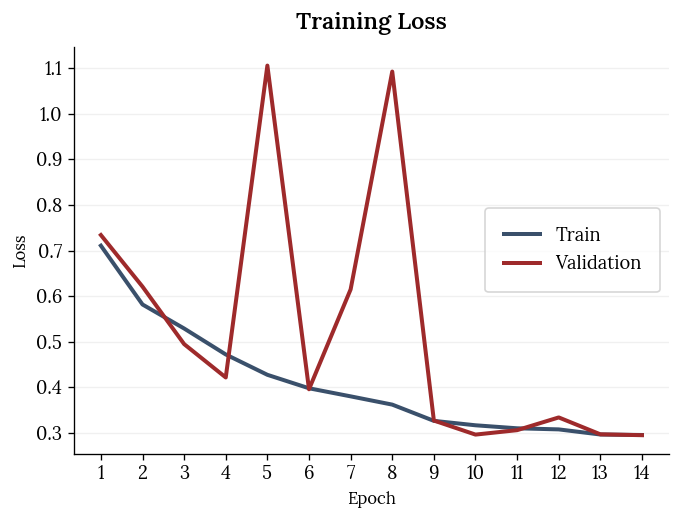

Saved: ../figures/final_cnn_training_loss.png


In [24]:
import pandas as pd
# Path to the file I generated
hist_path = "../models/lr_1e-3_baseline_history.csv"

df_hist = pd.read_csv(hist_path)

# Rebuild what Keras gives you: history.history is a dict of lists
history_like = {c: df_hist[c].tolist() for c in df_hist.columns}

# If your CSV includes an epoch column, drop it (optional)
history_like.pop("epoch", None)

epochs = range(1, len(history_like["loss"]) + 1)

# Your existing plotting code, but replace history_cnn.history[...] with history_like[...]
fig, ax = plt.subplots(figsize=(6.4, 4.4))

ax.plot(epochs, history_like["loss"], label="Train", linewidth=2.4, color=train_color)
ax.plot(epochs, history_like["val_loss"], label="Validation", linewidth=2.4, color=val_color)

ax.set_title("Training Loss", fontsize=14, fontweight="bold", y=1.02)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_xticks(list(epochs))

ax.grid(True, axis="y", alpha=0.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(fontsize=11, borderpad=1, loc="right")

out_path = os.path.join(figures_dir, "final_cnn_training_loss.png")
fig.savefig(out_path, dpi=220, bbox_inches="tight", pad_inches=0.02)
plt.show()
plt.close(fig)

print(f"Saved: {out_path}")

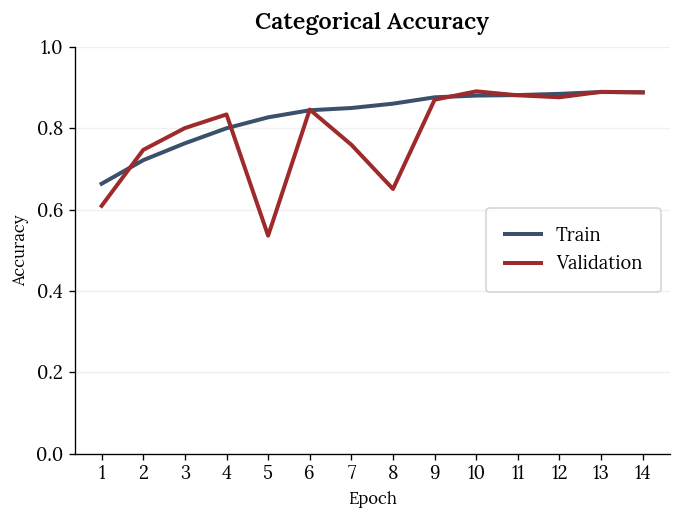

Saved: ../figures/final_cnn_training_accuracy.png


In [26]:
# Accuracy Figure
fig, ax = plt.subplots(figsize=(6.4, 4.4))

ax.plot(epochs, history_like["cat_acc"], label="Train", linewidth=2.4, color=train_color)
ax.plot(epochs, history_like["val_cat_acc"], label="Validation", linewidth=2.4, color=val_color)

ax.set_title("Categorical Accuracy", fontsize=14, fontweight="bold", y=1.02)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_xticks(epochs)
ax.set_ylim(0, 1)

ax.grid(True, axis="y", alpha=0.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(fontsize=11, borderpad = 1, loc='right')

out_path = os.path.join(figures_dir, "final_cnn_training_accuracy.png")
fig.savefig(out_path, dpi=220, bbox_inches="tight", pad_inches=0.02)
plt.show()
plt.close(fig)

print(f"Saved: {out_path}")

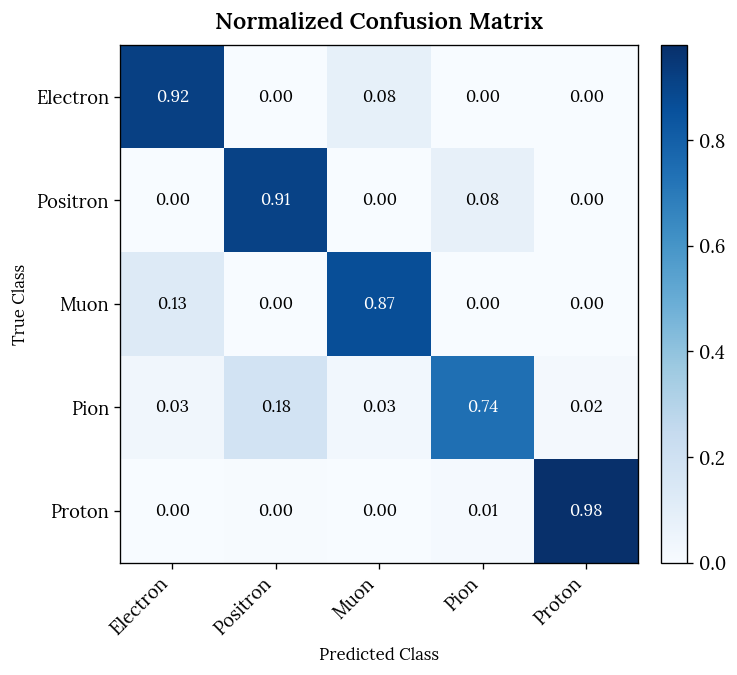

Saved: ../figures/final_cnn_confusion_matrix.png


In [21]:
# Confusion Matrix Figure
cm = confusion_matrix(y_true_cls, y_pred_cls)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6.2, 5.6))

im = ax.imshow(cm_norm, cmap="Blues")

ax.set_title("Normalized Confusion Matrix", fontsize=14, fontweight="bold", pad=10)
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")

ax.set_xticks(np.arange(len(particle_names)))
ax.set_yticks(np.arange(len(particle_names)))
ax.set_xticklabels(particle_names, rotation=45, ha="right")
ax.set_yticklabels(particle_names)

# Annotate cells
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(
            j, i,
            f"{cm_norm[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if cm_norm[i, j] > 0.5 else "black",
            fontsize=10
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

out_path = os.path.join(figures_dir, "final_cnn_confusion_matrix.png")
fig.savefig(out_path, dpi=220, bbox_inches="tight", pad_inches=0.02)
plt.show()
plt.close(fig)

print(f"Saved: {out_path}")

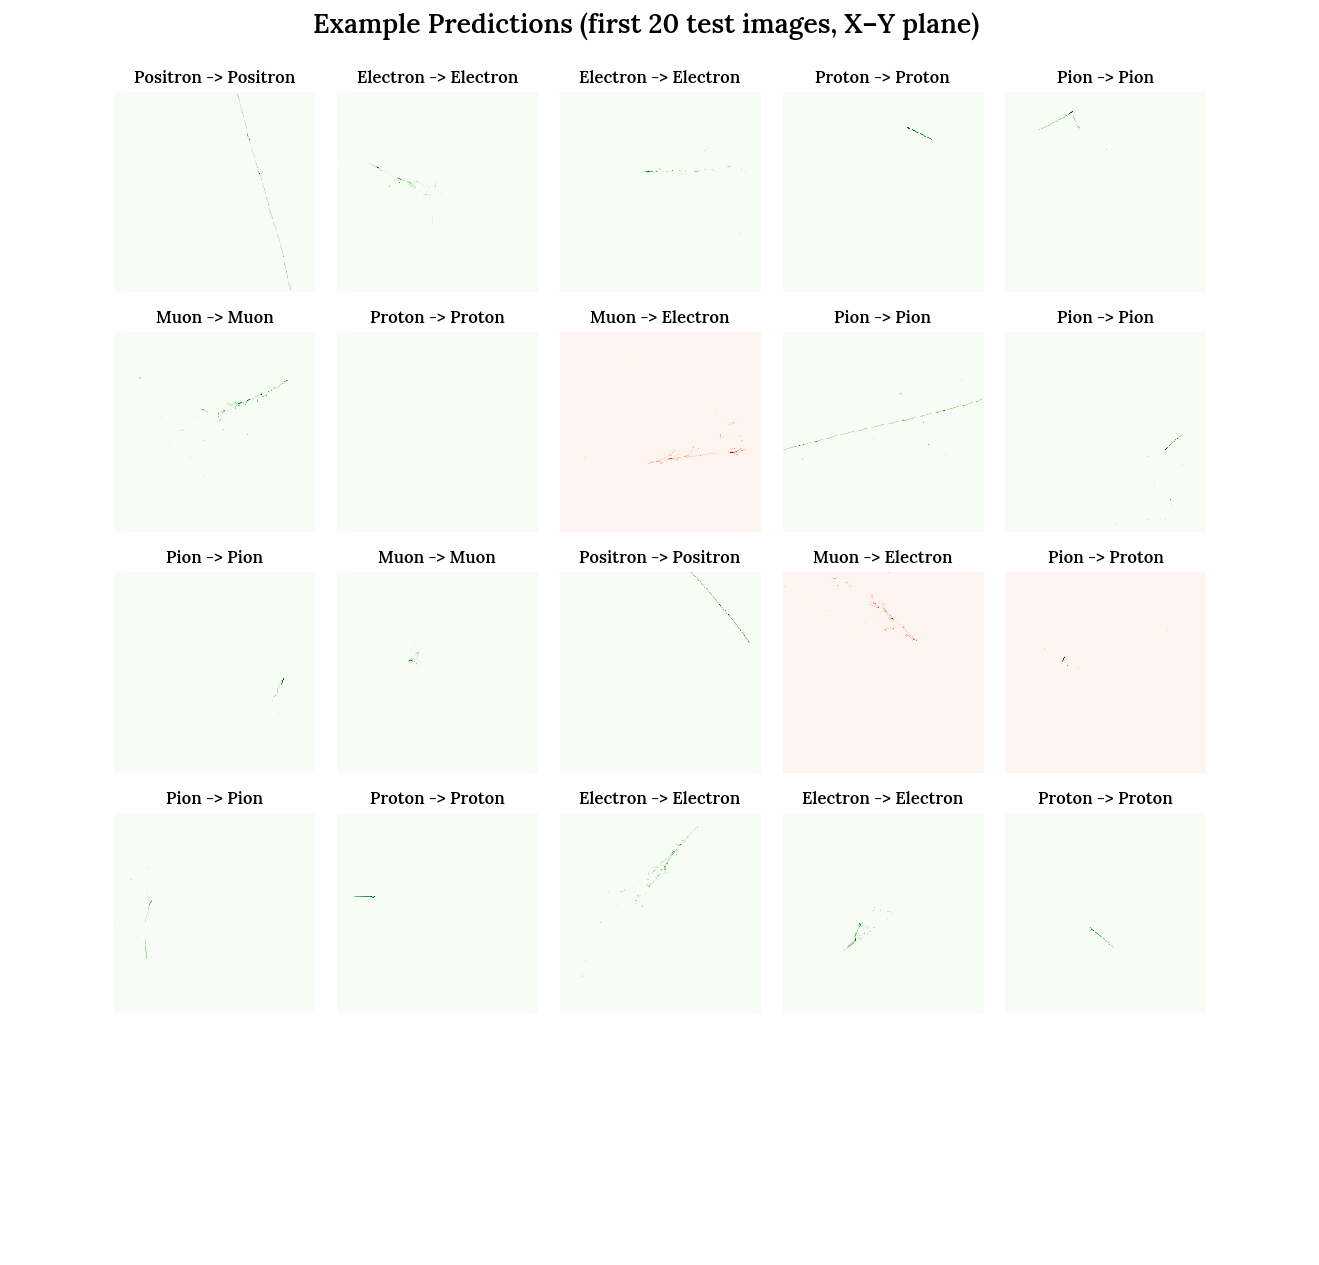

Saved: ../figures/cnn_example_predictions.png


In [42]:
# Classification gallery with correctness-based colormap

no_images = 20
num_cells = math.ceil(math.sqrt(no_images))

fig, axes = plt.subplots(
    nrows=num_cells,
    ncols=num_cells,
    figsize=(2.25 * num_cells, 2.25 * num_cells)
)

axes = np.atleast_2d(axes)

fig.subplots_adjust(
    left=0.03, right=0.99,
    top=0.90, bottom=0.04,
    wspace=-0.45, hspace=0.2
)

fig.suptitle(
    f"Example Predictions (first {no_images} test images, X–Y plane)",
    fontsize=16,
    fontweight="bold",
    y=0.96
)

ax_list = axes.ravel()

for i, ax in enumerate(ax_list):
    if i >= no_images:
        ax.axis("off")
        continue

    # Re-shape flattened image (X–Y plane)
    pixels = to_image(x_test[i])[0]

    y_true = int(y_true_cls[i])
    y_pred = int(y_pred_cls[i])

    true_label = particle_names[y_true]
    pred_label = particle_names[y_pred]

    correct = (y_true == y_pred)

    cmap = "Greens" if correct else "Reds"

    ax.imshow(pixels, cmap=cmap, interpolation="nearest")

    ax.set_xticks([])
    ax.set_yticks([])

    # Clean spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(
        f"{true_label} -> {pred_label}",
        fontsize=10,
    )

# Save figure
out_path = os.path.join(figures_dir, "cnn_example_predictions.png")
fig.savefig(out_path, dpi=220, bbox_inches="tight", pad_inches=0.02)

plt.show()
plt.close(fig)

print(f"Saved: {out_path}")